**Lab Sheet - 04**

Name - Saurabh Kumar Jha

Section - B

Roll.no. 53

CU ID - CU24250005

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
os.listdir('/content')

['.config', 'drive', 'sample.jpg', '.ipynb_checkpoints', 'sample_data']

In [3]:
image_path = '/content/sample.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image dimensions:", img.shape)

Image loaded successfully!
Image dimensions: (3376, 6000)


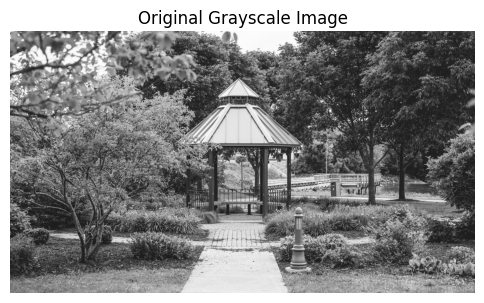

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

In [5]:
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

print("DFT computed successfully!")
print("DFT shape:", dft.shape)

DFT computed successfully!
DFT shape: (3376, 6000, 2)


In [7]:
dft_shift = np.fft.fftshift(dft)

In [8]:
magnitude_spectrum = cv2.magnitude(
    dft_shift[:, :, 0],
    dft_shift[:, :, 1]
)

magnitude_spectrum = np.log1p(magnitude_spectrum)

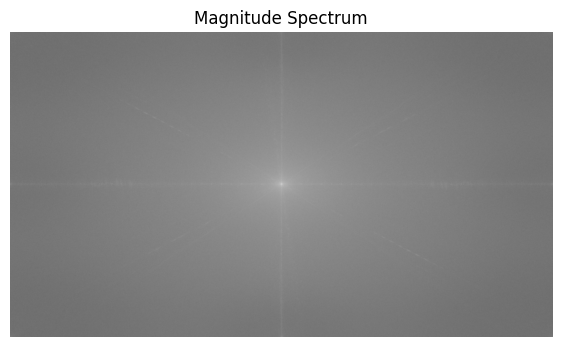

In [9]:
plt.figure(figsize=(7, 7))

plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.show()

In [10]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

radius = 50

low_pass_mask = np.zeros((rows, cols, 2), np.uint8)

cv2.circle(
    low_pass_mask,
    (ccol, crow),
    radius,
    (1, 1),
    -1
)

print("Low-pass filter created.")

Low-pass filter created.


In [11]:
low_pass_dft = dft_shift * low_pass_mask

In [12]:
low_pass_dft = np.fft.ifftshift(low_pass_dft)

In [13]:
low_pass_image = cv2.idft(low_pass_dft)

low_pass_image = cv2.magnitude(
    low_pass_image[:, :, 0],
    low_pass_image[:, :, 1]
)

low_pass_image = cv2.normalize(
    low_pass_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

low_pass_image = np.uint8(low_pass_image)

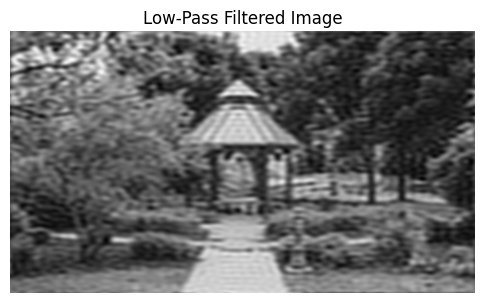

In [14]:
plt.figure(figsize=(6, 6))

plt.imshow(low_pass_image, cmap='gray')
plt.title('Low-Pass Filtered Image')
plt.axis('off')

plt.show()

In [15]:
high_pass_mask = np.ones((rows, cols, 2), np.uint8)

cv2.circle(
    high_pass_mask,
    (ccol, crow),
    radius,
    (0, 0),
    -1
)

print("High-pass filter created.")

High-pass filter created.


In [16]:
high_pass_dft = dft_shift * high_pass_mask

In [17]:
high_pass_dft = np.fft.ifftshift(high_pass_dft)

high_pass_image = cv2.idft(high_pass_dft)

high_pass_image = cv2.magnitude(
    high_pass_image[:, :, 0],
    high_pass_image[:, :, 1]
)

high_pass_image = cv2.normalize(
    high_pass_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

high_pass_image = np.uint8(high_pass_image)

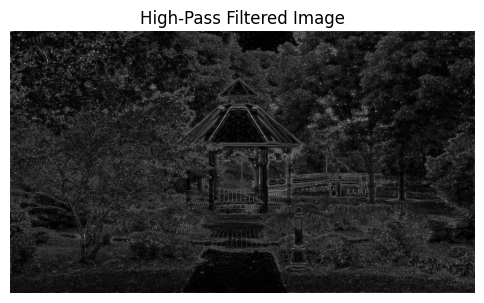

In [18]:
plt.figure(figsize=(6, 6))

plt.imshow(high_pass_image, cmap='gray')
plt.title('High-Pass Filtered Image')
plt.axis('off')

plt.show()

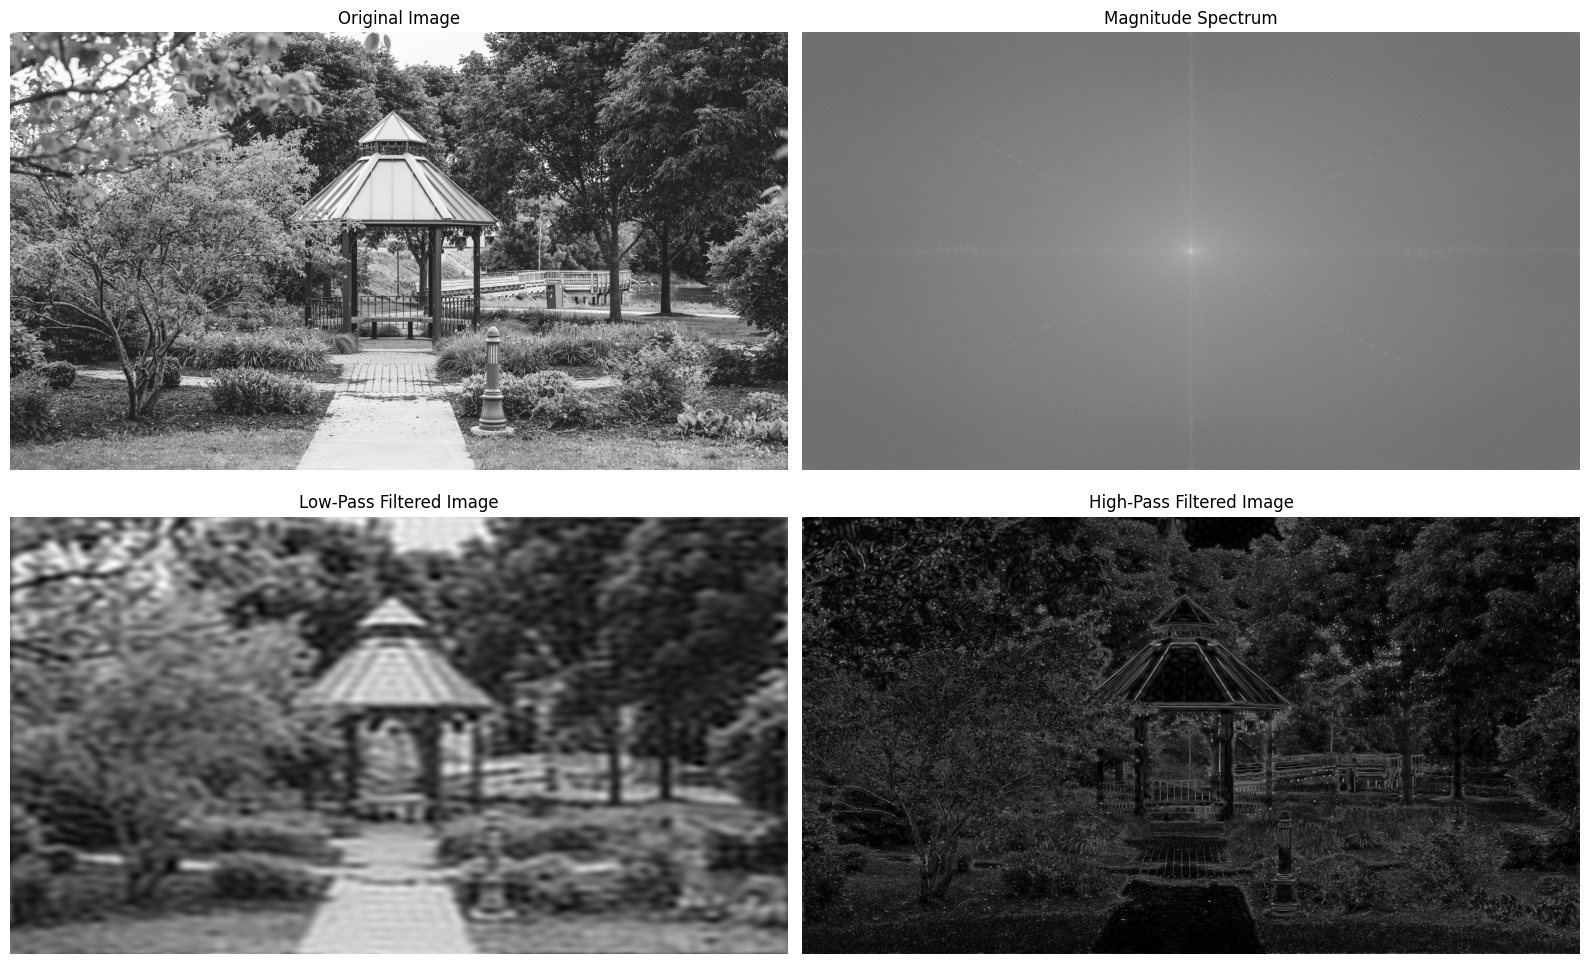

In [19]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(low_pass_image, cmap='gray')
plt.title('Low-Pass Filtered Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(high_pass_image, cmap='gray')
plt.title('High-Pass Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()

 Name - Alok Kumar Mavi

Section - B

Roll.no. 05

CU ID - CU240251681

# Lab Sheet 4 — Theory Questions and Answers

## Ques 1. What is the Fourier Transform? Why is it important in digital image processing?

**Ans-** The Fourier Transform is a mathematical technique used to convert an image from the **spatial domain** into the **frequency domain**. It represents an image in terms of its low-frequency and high-frequency components.

It is important in digital image processing because it allows different frequency components to be analyzed and modified separately. This makes it useful for **noise removal, image enhancement, image restoration, and feature extraction**.

---

## Ques 2. Differentiate between the spatial domain and the frequency domain.

**Ans-**

| Spatial Domain                                                             | Frequency Domain                                               |
| -------------------------------------------------------------------------- | -------------------------------------------------------------- |
| Works directly on image pixels.                                            | Works on the frequency components of an image.                 |
| Processing is performed based on pixel intensity values.                   | Processing is performed by modifying frequency components.     |
| Common techniques include smoothing, sharpening, and contrast enhancement. | Common techniques include Low-Pass and High-Pass filtering.    |
| It is generally easier to understand and implement.                        | It is useful for analyzing and manipulating image frequencies. |

---

## Ques 3. What is the significance of the Discrete Fourier Transform (DFT) in image processing?

**Ans-** The Discrete Fourier Transform (DFT) converts a digital image from the spatial domain into the frequency domain. It separates the image into different frequency components, making it possible to identify and manipulate low- and high-frequency information.

DFT is significant because it provides the basis for **frequency domain filtering**, noise reduction, image enhancement, restoration, and analysis of image features.

---

## Ques 4. Explain the purpose of shifting the zero-frequency component to the center of the frequency spectrum.

**Ans-** In the Fourier Transform output, the zero-frequency component is normally located at the corners of the spectrum. Shifting it to the center makes the frequency spectrum easier to visualize and analyze.

After shifting, the **low-frequency components appear near the center**, while the **high-frequency components appear farther from the center**. This arrangement makes the design and application of frequency filters more convenient.

---

## Ques 5. Compare Low-Pass Frequency Filters and High-Pass Frequency Filters with suitable applications.

**Ans-**

| Low-Pass Frequency Filter                           | High-Pass Frequency Filter                                         |
| --------------------------------------------------- | ------------------------------------------------------------------ |
| Allows low-frequency components to pass.            | Allows high-frequency components to pass.                          |
| Suppresses high-frequency components.               | Suppresses low-frequency components.                               |
| Produces a smoother image.                          | Enhances edges and fine details.                                   |
| Useful for noise reduction and smoothing.           | Useful for edge detection and sharpening.                          |
| Example application: removing high-frequency noise. | Example application: enhancing object boundaries and fine details. |

---

## Ques 6. What is the role of the Inverse Fourier Transform (IDFT) in image reconstruction?

**Ans-** The Inverse Fourier Transform converts a processed image from the **frequency domain back into the spatial domain**.

After applying a frequency filter, the filtered frequency components are transformed back using IDFT to produce the reconstructed image. Therefore, IDFT is essential for viewing and analyzing the final filtered image in its normal pixel representation.

---

## Ques 7. Why is frequency domain filtering preferred for certain image enhancement tasks?

**Ans-** Frequency domain filtering is preferred for certain image enhancement tasks because it allows specific frequency components to be selectively modified. Low-frequency information can be preserved or enhanced, while high-frequency information can be suppressed or emphasized according to the requirement.

This makes frequency domain filtering particularly useful for **noise removal, smoothing, edge enhancement, image restoration, and feature extraction**.

---

## Ques 8. Mention four real-world applications where Fourier Transform is used in computer vision and image analysis.

**Ans-**

1. **Medical image enhancement** — improving and analyzing medical images such as scans.
2. **Satellite image analysis** — processing and enhancing satellite imagery.
3. **Image restoration** — reducing noise and correcting degraded images.
4. **Biometric systems** — analyzing image features for applications such as identification and recognition.

---

## Ques 9. Compare frequency domain filtering with spatial domain filtering based on computational efficiency and practical applications.

**Ans-** Spatial domain filtering operates directly on image pixels and is generally simple to implement for basic operations such as smoothing and sharpening.

Frequency domain filtering first transforms the image using the Fourier Transform, processes its frequency components, and then reconstructs the image using the Inverse Fourier Transform. Although this involves additional transformation steps, frequency domain techniques can be more efficient for **certain large-scale filtering operations** and provide greater control over specific frequency components.

Therefore, spatial filtering is commonly used for straightforward local image operations, while frequency filtering is particularly useful for **noise removal, image restoration, enhancement, and frequency-based analysis**.

---

## Ques 10. How does frequency domain filtering improve the performance of image restoration and feature extraction techniques?

**Ans-** Frequency domain filtering improves image restoration by allowing unwanted frequency components, such as noise, to be selectively reduced while preserving useful image information.

For feature extraction, High-Pass filtering can emphasize **edges, boundaries, and fine details**, which are important features for computer vision systems. As a result, frequency domain filtering can improve the quality of the image and make important features easier to detect and analyze.
